# Ink Prediction Failure Atlas — walkthrough

Reproduces every headline number in the README from `data/atlas.csv` and
`data/labels/`. **No download, no GPU, no model** — the heavy step (scoring 46,764
windows of published ds8 JPEGs) already happened; this notebook re-derives the
conclusions from its output so you can check them without re-running it.

Needs only `numpy` (and `matplotlib` for the last two plots).

In [1]:
import csv, os, collections
import numpy as np

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else "."
D = lambda *p: os.path.join(ROOT, "data", *p)

INK_FLOOR = 0.05   # see README correction 1; set to 0 to reproduce every number without it

def load(path):
    with open(path, encoding="utf-8") as f:
        return list(csv.DictReader(f))

atlas = load(D("atlas.csv"))

# `key` is the prediction's S3 path, and the only unique identifier. (scroll, segment,
# recipe) is NOT unique - the same segment is published twice under one recipe label - and
# grouping by it merged distinct models into one row in the first published version.
for r in atlas:
    r["_s"] = 0.0 if float(r["frac_above"]) < INK_FLOOR else float(r["mass_letter"])
    step = int(r["window_px"]) // 2
    r["_tile"] = (int(r["y0"]) // step) % 2 == 0 and (int(r["x0"]) // step) % 2 == 0

# The atlas strides by HALF a window in both axes, so every patch of papyrus is covered
# about four times and adjacent rows share pixels. Percentages over the full grid are
# percentages of nothing physical, and their confidence intervals come out twice too narrow.
# Everything statistical below runs on the non-overlapping subset.
tile = [r for r in atlas if r["_tile"]]
score = np.array([r["_s"] for r in tile])

print(f"windows            : {len(atlas):,}")
print(f"  non-overlapping  : {len(tile):,}")
print(f"predictions scored : {len({r['key'] for r in atlas})}")
print(f"  by (scroll,seg,recipe), the WRONG key: "
      f"{len({(r['scroll'], r['segment'], r['recipe']) for r in atlas})}")
print(f"segments           : {len({(r['scroll'], r['segment']) for r in atlas})}")
print(f"scrolls            : {sorted({r['scroll'] for r in atlas})}")

man = load(D("atlas_manifest.csv"))
counts = collections.Counter(r["status"] for r in man)
print(f"\npublished predictions: {len(man)} -> "
      + "  ".join(f"{k}={v}" for k, v in counts.most_common()))
print(f"The {len(man) - counts['scored']} unscored ones are why the denominator has to be "
      f"stated, not assumed.")


windows            : 46,764
  non-overlapping  : 12,387
predictions scored : 374
  by (scroll,seg,recipe), the WRONG key: 321
segments           : 226
scrolls            : ['PHerc0139', 'PHerc0172', 'PHerc0343P', 'PHerc0500P2', 'PHerc0814', 'PHerc1667', 'PHercParis4']

published predictions: 423 -> scored=374  too_small=25  low_coverage=22  no_pitch=2
The 49 unscored ones are why the denominator has to be stated, not assumed.


## 1. Every window covers the same physical area

This is what makes "% of windows" mean "% of papyrus area", and it is the fix for the
third of three unit bugs described in the README. The window is defined in **microns**,
so its size in pixels differs per prediction — a fixed pixel window would cover 11× more
papyrus on the 7.91 µm scan than on the 2.4 µm ones, and a mass fraction over 11× the
area dilutes.

In [2]:
seen = {}
for r in atlas:
    seen.setdefault(float(r["pitch_um"]), set()).add(int(r["window_px"]))

print(f"{'pitch um/px':>12}{'window px':>12}{'physical mm':>14}")
for pitch in sorted(seen):
    for wpx in sorted(seen[pitch]):
        print(f"{pitch:>12}{wpx:>12}{wpx * pitch / 1000:>14.2f}")
print("\nSame physical size everywhere (the 2488 px row is the 7.91 um scan).")

 pitch um/px   window px   physical mm
       2.215        8872         19.65
       2.258        8704         19.65
       2.399        8192         19.65
         2.4        8192         19.66
        7.91        2488         19.68

Same physical size everywhere (the 2488 px row is the 7.91 um scan).


## 2. The score is not a brightness proxy

The obvious failure mode for a legibility metric is that it silently measures *amount of
ink*. An early version did: it correlated 0.773 with the fraction of pixels above
threshold, which is a brightness meter with extra steps. Making the component-size
criterion a **band** instead of a lower bound (a saturated white smear is one enormous
connected component, and scores perfectly under a lower bound) brought it down.

In [3]:
frac_above = np.array([float(r["frac_above"]) for r in tile])
median_ext = np.array([float(r["median_extent"]) for r in tile])
smear = np.array([float(r["mass_smear"]) for r in tile])
raw = np.array([float(r["mass_letter"]) for r in tile])   # before the ink floor

print(f"corr(score, frac_above)    : {np.corrcoef(raw, frac_above)[0,1]:.3f}   (no floor)")
print(f"                             {np.corrcoef(score, frac_above)[0,1]:.3f}   (with floor)")
print(f"corr(score, median_extent) : {np.corrcoef(raw, median_ext)[0,1]:.3f}")
print(f"corr(score, mass_smear)    : {np.corrcoef(raw, smear)[0,1]:.3f}")
print("\nThe floor raises the frac_above correlation on purpose: zeroing near-empty windows")
print("couples the score to ink quantity at the bottom end. That is the cost of the guard.")
print("\nscore distribution (non-overlapping windows):")
for q in (1, 10, 25, 50, 75, 90, 99):
    print(f"  p{q:<3} {np.percentile(raw, q):.4f}")


corr(score, frac_above)    : 0.217   (no floor)


                             0.396   (with floor)
corr(score, median_extent) : 0.414
corr(score, mass_smear)    : -0.431

The floor raises the frac_above correlation on purpose: zeroing near-empty windows
couples the score to ink quantity at the bottom end. That is the cost of the guard.

score distribution (non-overlapping windows):
  p1   0.1032
  p10  0.4451
  p25  0.5866
  p50  0.7079
  p75  0.7970
  p90  0.8612
  p99  0.9330


## 3. Calibration against the blind labels

The labels were produced without seeing the score: the sheets carry an index and nothing
else, in shuffled order, and the index → window key was written first. See
`data/labels/README.md`.

**AUC is reported first because it has no threshold to tune.** A metric can always be made
to look good at *some* cutoff; it cannot be made to look good under AUC.

In [4]:
key = load(D("labels", "labeling_key.csv"))
lab = {int(r["i"]): r["label"].strip() for r in load(D("labels", "labels.csv")) if r["label"].strip()}

# The score comes from the ATLAS, never from the labelling key. The key stores a snapshot
# taken when the sample was drawn; the metric was fixed afterwards, and six of these rows
# kept their pre-fix value. Reading them back inflated the published AUC from 0.918 to 0.930.
at = {(r["scroll"], r["segment"], r["recipe"], r["y0"], r["x0"]): r for r in atlas}

joined, stale = [], 0
for r in key:
    i = int(r["i"])
    if i not in lab:
        continue
    a = at[(r["scroll"], r["segment"], r["recipe"], r["y0"], r["x0"])]
    stale += abs(float(a["mass_letter"]) - float(r["mass_letter"])) > 1e-6
    joined.append((a["_s"], lab[i]))

s = np.array([j[0] for j in joined])
y = [j[1] for j in joined]
print(f"{len(lab)} labels written, {len(joined)} join the current window grid")
print(f"key rows whose stored score no longer matches the atlas: {stale}")
print(dict(collections.Counter(y)))

print(f"\n{'label':<10}{'n':>5}{'mean':>8}{'p25':>8}{'median':>8}{'p75':>8}")
for k in ("text", "partial", "speckle"):
    v = s[[i for i, t in enumerate(y) if t == k]]
    print(f"{k:<10}{len(v):>5}{v.mean():>8.3f}{np.percentile(v,25):>8.3f}"
          f"{np.median(v):>8.3f}{np.percentile(v,75):>8.3f}")


160 labels written, 125 join the current window grid
key rows whose stored score no longer matches the atlas: 0
{'speckle': 41, 'text': 46, 'partial': 38}

label         n    mean     p25  median     p75
text         46   0.922   0.902   0.936   0.953
partial      38   0.782   0.743   0.824   0.891
speckle      41   0.462   0.000   0.537   0.750


In [5]:
def auc(pos, neg):
    """Mann-Whitney U: P(a random positive outranks a random negative)."""
    allv = np.concatenate([pos, neg])
    order = allv.argsort()
    ranks = np.empty(len(allv), float)
    ranks[order] = np.arange(1, len(allv) + 1)
    _, inv, cnt = np.unique(allv, return_inverse=True, return_counts=True)
    sums = np.zeros(len(cnt)); np.add.at(sums, inv, ranks)   # average over ties
    ranks = (sums / cnt)[inv]
    return (ranks[:len(pos)].sum() - len(pos)*(len(pos)+1)/2) / (len(pos)*len(neg))

pos = s[[i for i, t in enumerate(y) if t == "text"]]
neg = s[[i for i, t in enumerate(y) if t != "text"]]
print(f"AUC (text vs rest) = {auc(pos, neg):.3f}    (0.5 = worthless, 1.0 = perfect)\n")

print(f"{'thresh':>7}{'TP':>5}{'FP':>5}{'FN':>5}{'prec':>7}{'recall':>8}{'F1':>7}")
best = None
for t in np.arange(0.80, 1.00, 0.025):
    tp, fp, fn = int((pos>=t).sum()), int((neg>=t).sum()), int((pos<t).sum())
    if tp == 0: continue
    p, rc = tp/(tp+fp), tp/(tp+fn); f1 = 2*p*rc/(p+rc)
    best = best if best and best[0] >= f1 else (f1, t, p, rc)
    print(f"{t:>7.3f}{tp:>5}{fp:>5}{fn:>5}{p:>7.3f}{rc:>8.3f}{f1:>7.3f}")
print(f"\nbest F1 = {best[0]:.3f} at {best[1]:.3f}  (precision {best[2]:.3f}, recall {best[3]:.3f})")
THRESH = round(best[1], 3)

AUC (text vs rest) = 0.931    (0.5 = worthless, 1.0 = perfect)

 thresh   TP   FP   FN   prec  recall     F1
  0.800   45   30    1  0.600   0.978  0.744
  0.825   45   25    1  0.643   0.978  0.776
  0.850   42   19    4  0.689   0.913  0.785
  0.875   41   16    5  0.719   0.891  0.796
  0.900   36    8   10  0.818   0.783  0.800
  0.925   27    3   19  0.900   0.587  0.711
  0.950   13    1   33  0.929   0.283  0.433
  0.975    2    0   44  1.000   0.043  0.083

best F1 = 0.800 at 0.900  (precision 0.818, recall 0.783)


## 4. The headline

Note the shape of the threshold sweep: the answer moves from 12.26% to 0.38% between 0.850
and 0.950. **The threshold is doing most of the work**, which is exactly why it has to be
calibrated against labels rather than picked off the distribution. An earlier version of
this project anchored it on two hand-verified zones from one segment of one scroll — the
scroll that then topped the resulting table.

In [6]:
def wilson(k, n, z=1.96):
    """Wilson interval: behaves at k=0, which the normal approximation does not."""
    p = k / n
    den = 1 + z*z/n
    c = (p + z*z/(2*n)) / den
    h = z * np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / den
    return max(0.0, c - h), min(1.0, c + h)

print(f"corpus of {len(score):,} equal-area, NON-OVERLAPPING windows:\n")
for t in (0.80, 0.85, 0.875, 0.90, 0.95):
    k = int((score >= t).sum())
    lo, hi = wilson(k, len(score))
    mark = "  <- calibrated" if abs(t - THRESH) < 1e-9 else ""
    print(f"  >= {t:.3f}   {k:>6,}   {k/len(score):>6.2%}   CI95 [{lo:.2%}, {hi:.2%}]{mark}")

by = {}
for r in tile:
    d = by.setdefault(r["scroll"], [0, 0])
    d[0] += 1; d[1] += r["_s"] >= THRESH
print(f"\nper scroll at {THRESH}:")
print(f"{'scroll':<14}{'windows':>9}{'legible':>9}{'pct':>8}{'CI95':>20}")
for k, d in sorted(by.items(), key=lambda kv: -kv[1][1]/kv[1][0]):
    lo, hi = wilson(d[1], d[0])
    print(f"{k:<14}{d[0]:>9,}{d[1]:>9}{d[1]/d[0]:>8.2%}{f'[{lo:.2%}, {hi:.2%}]':>20}")
share = max(len(v) for v in [[r for r in tile if r["scroll"] == k] for k in by]) / len(tile)
print(f"\nCaveat: PHercParis4 is {share:.0%} of the non-overlapping windows, so the global")
print("average is de facto a PHercParis4 average. The small scrolls' intervals are too")
print("wide to rank against each other.")


corpus of 12,387 equal-area, NON-OVERLAPPING windows:

  >= 0.800    2,964   23.93%   CI95 [23.19%, 24.69%]
  >= 0.850    1,519   12.26%   CI95 [11.70%, 12.85%]
  >= 0.875      932    7.52%   CI95 [7.07%, 8.00%]
  >= 0.900      486    3.92%   CI95 [3.60%, 4.28%]  <- calibrated
  >= 0.950       47    0.38%   CI95 [0.29%, 0.50%]

per scroll at 0.9:
scroll          windows  legible     pct                CI95
PHerc1667           307       29   9.45%     [6.66%, 13.24%]
PHerc0814            13        1   7.69%     [1.37%, 33.31%]
PHercParis4       7,933      435   5.48%      [5.00%, 6.01%]
PHerc0172         3,710       20   0.54%      [0.35%, 0.83%]
PHerc0139           396        1   0.25%      [0.04%, 1.42%]
PHerc0343P            8        0   0.00%     [0.00%, 32.44%]
PHerc0500P2          20        0   0.00%     [0.00%, 16.11%]

Caveat: PHercParis4 is 64% of the non-overlapping windows, so the global
average is de facto a PHercParis4 average. The small scrolls' intervals are too
wide to r

## 5. Where it fails — the actionable output

A percentage says how much of a scroll is readable, not *where*. Predictions with **zero**
readable windows are the failure list; `data/hotspots.csv` and `data/segment_summary.csv`
carry full-resolution coordinates, so a fix has a before/after number instead of an opinion.

In [7]:
summ = load(D("segment_summary.csv"))
# A prediction whose coverage filter left almost nothing is unrankable, not 0% readable.
ranked = [r for r in summ if r["pct_text"] and int(r["windows"]) >= 20]
dead = [r for r in ranked if int(r["n_text"]) == 0]
print(f"{len(dead)} of {len(ranked)} ranked predictions ({len(dead)/len(ranked):.1%}) "
      f"have ZERO readable windows\n")
for k, n in collections.Counter(r["scroll"] for r in dead).most_common():
    print(f"  {k:<14}{n:>4}")

fail = load(D("failures.csv"))
assert len(fail) == len(dead), (len(fail), len(dead))
print(f"\nSame list, with coordinates, in data/failures.csv. First rows:")
print(f"{'scroll':<13}{'segment':<28}{'win':>5}{'max':>7}{'best y0,x0':>16}")
for r in fail[:8]:
    print(f"{r['scroll']:<13}{r['segment'][:27]:<28}{int(r['windows']):>5}"
          f"{float(r['max_score']):>7.3f}{r['best_y0'] + ',' + r['best_x0']:>16}")

print(f"\nbest predictions:")
print(f"{'scroll':<13}{'segment':<28}{'win':>5}{'pct':>8}{'CI95':>20}")
for r in ranked[:10]:
    ci = f"[{float(r['ci_lo']):.1%}, {float(r['ci_hi']):.1%}]"
    print(f"{r['scroll']:<13}{r['segment'][:27]:<28}{int(r['windows']):>5}"
          f"{float(r['pct_text']):>8.1%}{ci:>20}")


91 of 170 ranked predictions (53.5%) have ZERO readable windows

  PHerc0172       67
  PHercParis4     23
  PHerc1667        1

Same list, with coordinates, in data/failures.csv. First rows:
scroll       segment                       win    max      best y0,x0
PHerc0172    20251210153304-w058_2025121    20  0.878       1240,3720
PHerc0172    20250926132117-w083_2025092    22  0.900       7440,1240
PHercParis4  20260623154006-w085-088       128  0.925     40960,77824
PHerc0172    20250926114310-w080_2025092    20  0.901       9920,8680
PHerc0172    20251111010954-w068_2025111    30  0.910       3720,9920
PHerc0172    20250926122938-w082_2025092    22  0.878          7440,0
PHercParis4  20260623151729-w073-076        27  0.867     17408,60928
PHerc0172    20251210160810-w057_2025121    20  0.846          0,8680

best predictions:
scroll       segment                       win     pct                CI95
PHercParis4  20231022170901                 28   42.9%      [26.5%, 60.9%]
PHercPari

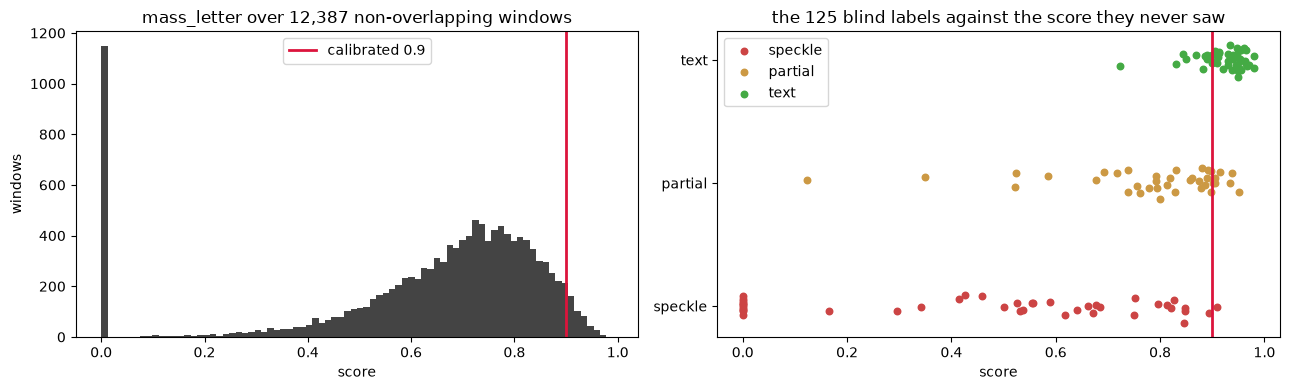

In [8]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
order = ["speckle", "partial", "text"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(score, bins=80, color="#444")
ax[0].axvline(THRESH, color="crimson", lw=2, label=f"calibrated {THRESH}")
ax[0].set_title(f"mass_letter over {len(score):,} non-overlapping windows")
ax[0].set_xlabel("score"); ax[0].set_ylabel("windows"); ax[0].legend()

for k, c in zip(order, ("#c44", "#c94", "#4a4")):
    v = s[[i for i, t in enumerate(y) if t == k]]
    ax[1].scatter(v, order.index(k) + rng.normal(0, 0.06, len(v)), c=c, s=22, label=k)
ax[1].axvline(THRESH, color="crimson", lw=2)
ax[1].set_title(f"the {len(y)} blind labels against the score they never saw")
ax[1].set_xlabel("score")
ax[1].set_yticks([0, 1, 2])
ax[1].set_yticklabels(order)
ax[1].legend()
plt.tight_layout()
# figures/calibration.png in the README is this cell's output, so it cannot go stale.
plt.savefig(os.path.join(ROOT, "figures", "calibration.png"), dpi=110)


The right-hand panel is the honest picture of this metric. `text` and `speckle` separate
cleanly. `partial` straddles the line, and some speckle reaches 0.75 — which is why
precision at the calibrated threshold is 0.818 and not higher.

**This is a screener, not a verdict.** It tells you where to look, not what is there. See
the limitations section of the repository README before citing any of these numbers.